# 04 - Evaluation Scores Analysis (EDA) 

## Overview
This notebook provides a **comprehensive, deep-dive analysis** of all VLM evaluation metrics available in the Artemis system. We evaluate the consistency, distribution, and reliability of different scoring mechanisms.

## Metrics Analyzed
1.  **VLM Judge (Molmo-72B)**: Neural judge providing scores (0-10) and comparative rankings.
2.  **Glider Score**: Rule-based rubric evaluation (0-5).
3.  **Semantic F1**: Bag-of-words overlap between prediction and ground truth.
4.  **Exact Match**: Strict string matching (Binary).
5.  **InternVL Judge**: Secondary neural judge (optional/experimental).
6.  **Confidence**: Model's self-reported confidence.

## Goal
To understand which models perform best according to *robust* metrics and determine if our automated evaluators align with each other.

In [29]:
# === Imports & Setup ===
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import text

# Path Setup
NOTEBOOK_DIR = Path.cwd()
ARTEMIS_DIR = NOTEBOOK_DIR.parent.parent.parent.parent
sys.path.append(str(ARTEMIS_DIR))

from artemis_final.ares.db.connection import get_engine
from artemis_final.ares.configs.db_config import MODEL_NAMES

# Plotting Style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 7)
plt.rcParams['font.size'] = 11
sns.set_palette("viridis")

engine = get_engine()
print(" Environment Setup Complete")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
✅ Environment Setup Complete


## 1. Data Loading 
Fetching data using a **3-Way Join** to ensure we have Samples, Responses, and Evaluations aligned.

In [31]:
# === Data Loading ===
query = """
SELECT 
    r.sample_id,
    r.model_name,
    r.ok,
    r.is_correct,
    r.confidence_score,
    r.latency_ms,
    r.estimated_cost_usd,
    
    -- Task Info
    s.router_task,
    s.source_dataset,
    
    -- Evaluation Metrics
    e.glider_score,
    e.judge_molmo_score,
    e.judge_molmo_rank_group,
    e.semantic_f1_f1
    
FROM vlm_responses r
JOIN vlm_samples s ON r.sample_id = s.sample_id
LEFT JOIN vlm_evaluations e ON r.sample_id = e.sample_id AND r.model_name = e.model_name
WHERE r.ok = true
"""

df = pd.read_sql(query, engine)
print(f" Loaded {len(df):,} rows")

# Preprocessing / Casting
numeric_cols = ['glider_score', 'judge_molmo_score', 'semantic_f1_f1']
for c in numeric_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors='coerce')

df.head()

📊 Loaded 339,056 rows


,sample_id,model_name,ok,is_correct,confidence_score,latency_ms,estimated_cost_usd,router_task,source_dataset,glider_score,judge_molmo_score,judge_molmo_rank_group,semantic_f1_f1
0,chartqa_206_9567fd05,qwen2_5_vl_3b,True,True,0.979876,2792.0,0.000067,chart_reasoning,cauldron,5.0,10.0,1.0,NaN
1,websight_674_8508636f,gemma_3_27b,True,False,0.908775,14736.0,0.000145,web_understanding,cauldron,4.0,6.0,2.0,NaN
2,websight_787_e5551094,gemma_3_27b,True,False,0.898536,25359.0,0.000222,web_understanding,cauldron,4.0,NaN,NaN,NaN
3,websight_895_9027b791,gemma_3_27b,True,False,0.909984,28004.0,0.000243,web_understanding,cauldron,4.0,1.0,3.0,NaN
4,websight_935_058a4204,qwen3_vl_8b_thinking,True,False,0.874541,20002.0,0.005213,web_understanding,cauldron,4.0,9.0,1.0,NaN


## 2. Metric Availability Analysis ️‍️
Before analyzing scores, let's see which metrics are actually populated.

/var/folders/l8/nbcrmtqs2838_6yr979chd1m0000gn/T/ipykernel_96083/3267385243.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=coverage.index, y=coverage.values, palette="Blues_d")


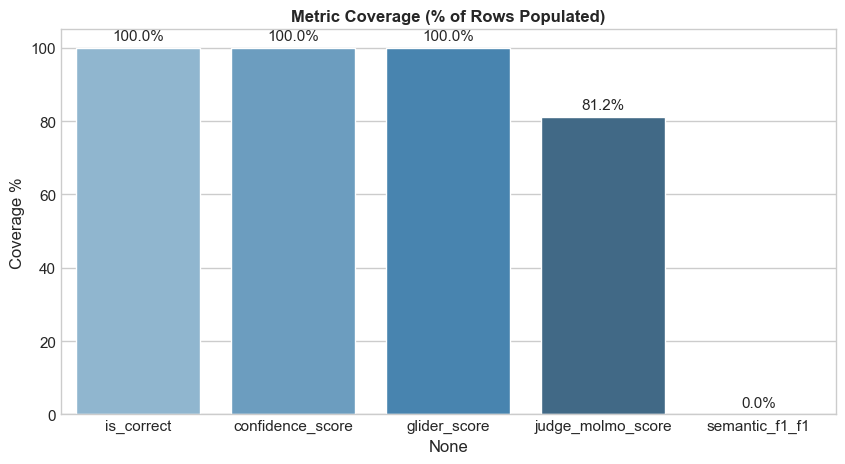

In [32]:
# Calculate coverage
metrics = ['is_correct', 'confidence_score', 'glider_score', 'judge_molmo_score', 'semantic_f1_f1']
coverage = df[metrics].notnull().mean() * 100

plt.figure(figsize=(10, 5))
sns.barplot(x=coverage.index, y=coverage.values, palette="Blues_d")
plt.title("Metric Coverage (% of Rows Populated)", fontweight='bold')
plt.ylabel("Coverage %")
plt.ylim(0, 105)
for i, v in enumerate(coverage.values):
    plt.text(i, v + 2, f"{v:.1f}%", ha='center')
plt.show()

## 3. Cross-Metric Correlation 
Do our different judges agree? A high correlation between `judge_molmo_score` and `glider_score` suggests reliability.

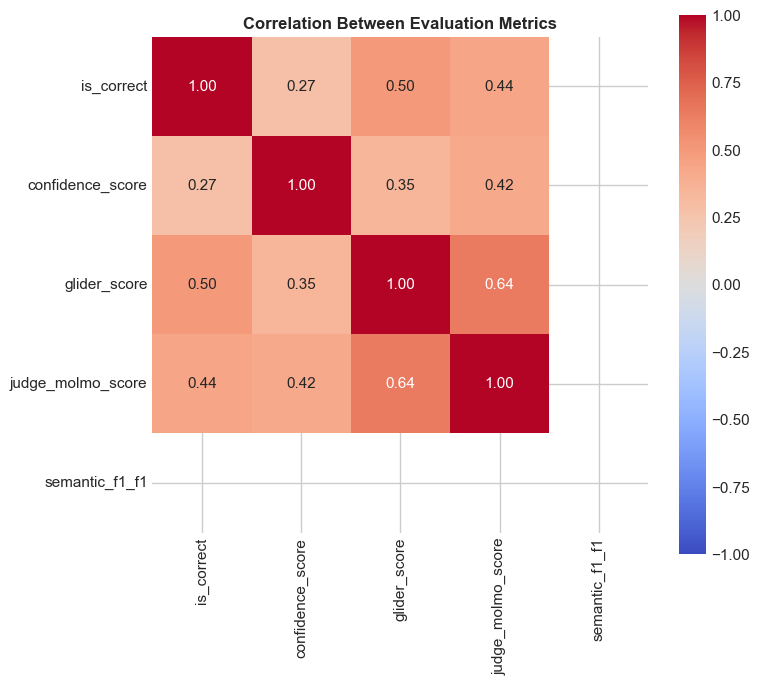

In [33]:
# Correlation Matrix
valid_metrics = [m for m in metrics if m in df.columns]
if len(valid_metrics) > 1:
    corr = df[valid_metrics].corr()
    
    plt.figure(figsize=(8, 7))
    sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", square=True, vmin=-1, vmax=1)
    plt.title("Correlation Between Evaluation Metrics", fontweight='bold')
    plt.show()
else:
    print("Not enough metrics for correlation analysis")

## 4. Deep Dive: Molmo Judge (Neural Evaluator) 
Molmo-72B is our primary neural judge. Let's analyze its score distributions and rankings.

/var/folders/l8/nbcrmtqs2838_6yr979chd1m0000gn/T/ipykernel_96083/392128359.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='model_name', y='judge_molmo_score', inner='quartile', palette="viridis")


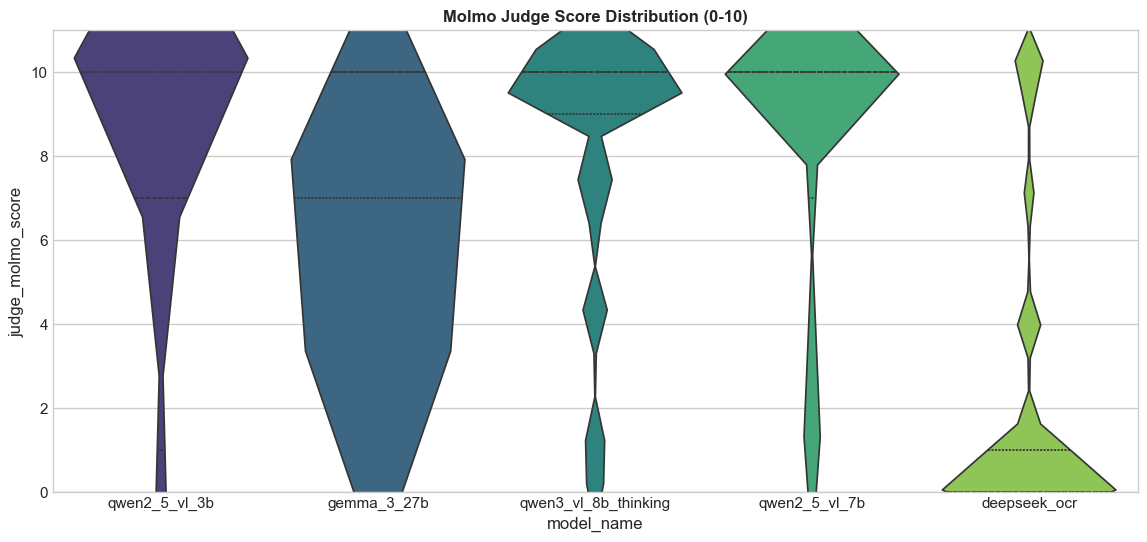


Average Molmo Scores:
                          mean       std   50%
model_name                                    
qwen3_vl_8b_thinking  8.890447  2.465451  10.0
qwen2_5_vl_7b         7.742575  3.730160  10.0
gemma_3_27b           7.592953  4.092184  10.0
qwen2_5_vl_3b         6.052845  4.552077   7.0
deepseek_ocr          1.898716  3.244620   0.0


In [34]:
# Molmo Score Distribution by Model
if 'judge_molmo_score' in df.columns:
    plt.figure(figsize=(14, 6))
    sns.violinplot(data=df, x='model_name', y='judge_molmo_score', inner='quartile', palette="viridis")
    plt.title("Molmo Judge Score Distribution (0-10)", fontweight='bold')
    plt.ylim(0, 11)
    plt.show()
    
    # Summary Stats
    print("\nAverage Molmo Scores:")
    print(df.groupby('model_name')['judge_molmo_score'].describe()[['mean', 'std', '50%']].sort_values('mean', ascending=False))

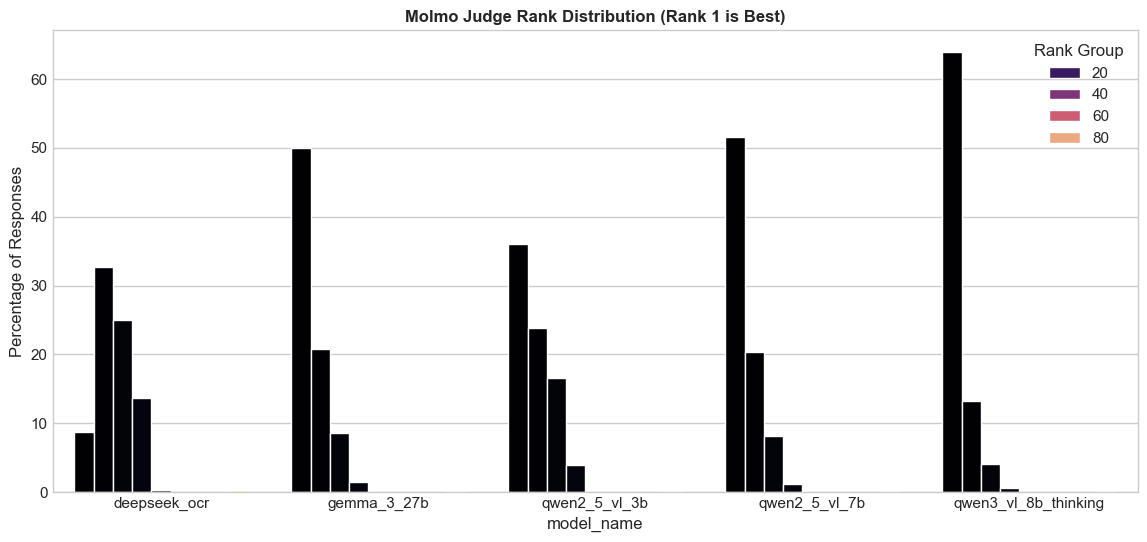

In [35]:
# Molmo Rank Analysis (How often is model #1?)
if 'judge_molmo_rank_group' in df.columns:
    rank_counts = df.groupby(['model_name', 'judge_molmo_rank_group']).size().reset_index(name='count')
    total_counts = df.groupby('model_name').size().reset_index(name='total')
    rank_data = rank_counts.merge(total_counts, on='model_name')
    rank_data['percentage'] = rank_data['count'] / rank_data['total'] * 100
    
    plt.figure(figsize=(14, 6))
    sns.barplot(data=rank_data, x='model_name', y='percentage', hue='judge_molmo_rank_group', palette='magma')
    plt.title("Molmo Judge Rank Distribution (Rank 1 is Best)", fontweight='bold')
    plt.ylabel("Percentage of Responses")
    plt.legend(title="Rank Group")
    plt.show()

## 5. Standard Metrics: Glider & Semantic F1 
Looking at rule-based (Glider) and n-gram overlap (Semantic F1) metrics.

/var/folders/l8/nbcrmtqs2838_6yr979chd1m0000gn/T/ipykernel_96083/3945199205.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='model_name', y='semantic_f1_f1', ax=axes[1], palette="Set2")


UnboundLocalError: cannot access local variable 'boxprops' where it is not associated with a value

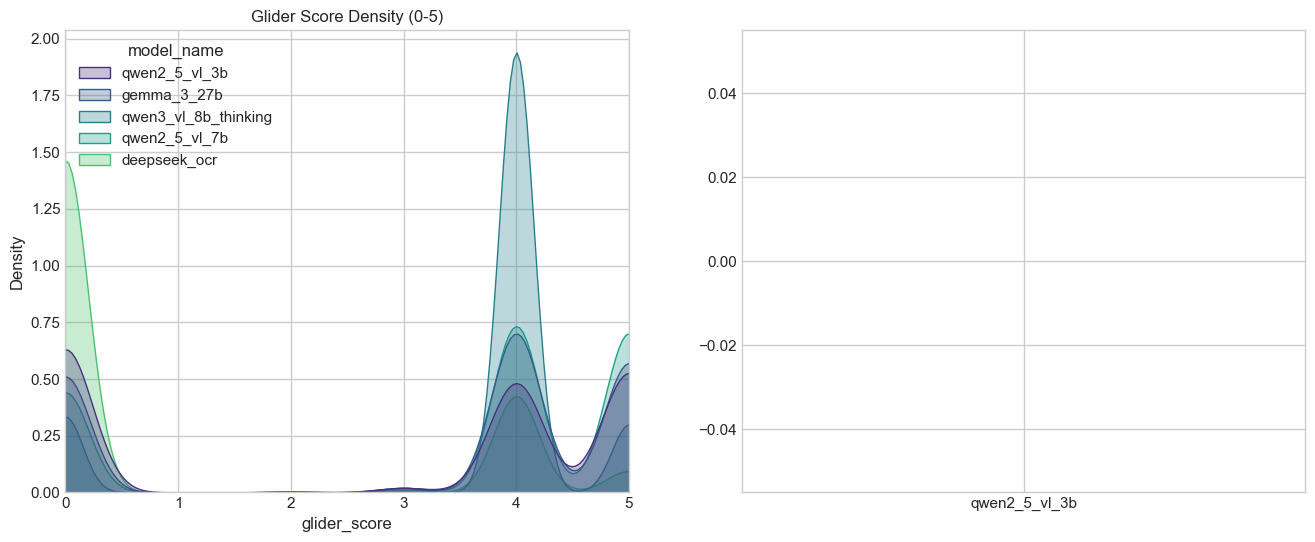

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Glider (KDE)
if 'glider_score' in df.columns:
    sns.kdeplot(data=df, x='glider_score', hue='model_name', fill=True, common_norm=False, alpha=0.3, ax=axes[0])
    axes[0].set_title("Glider Score Density (0-5)")
    axes[0].set_xlim(0, 5)

# Semantic F1 (Box)
if 'semantic_f1_f1' in df.columns:
    box_data = df[['model_name', 'semantic_f1_f1']].dropna()
    if not box_data.empty:
        sns.boxplot(data=box_data, x='model_name', y='semantic_f1_f1', ax=axes[1], palette="Set2")
    else:
        axes[1].text(0.5, 0.5, "No semantic F1 data available", ha='center', va='center', fontsize=12, alpha=0.7)
    axes[1].set_title("Semantic F1 Score Distribution (0-1)")
    axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 6. Calibration Analysis 
Does high model confidence actually mean high quality output? We plot Binned Confidence vs Avg Molmo Score.

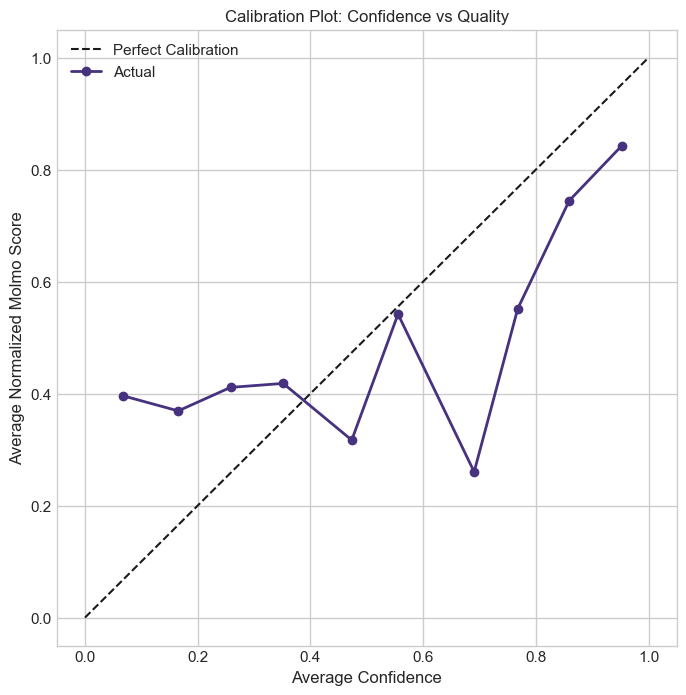

In [37]:
if 'judge_molmo_score' in df.columns and 'confidence_score' in df.columns:
    # Bin confidence into 10 bins
    df['conf_bin'] = pd.cut(df['confidence_score'], bins=10, labels=False)
    calibration = df.groupby('conf_bin')[['confidence_score', 'judge_molmo_score']].mean()
    # Normalize Molmo to 0-1 for comparison
    calibration['molmo_norm'] = calibration['judge_molmo_score'] / 10.0
    
    plt.figure(figsize=(8, 8))
    plt.plot([0, 1], [0, 1], 'k--', label="Perfect Calibration")
    plt.plot(calibration['confidence_score'], calibration['molmo_norm'], 'o-', linewidth=2, label="Actual")
    
    plt.xlabel("Average Confidence")
    plt.ylabel("Average Normalized Molmo Score")
    plt.title("Calibration Plot: Confidence vs Quality")
    plt.legend()
    plt.show()

## 7. Performance by Task 
Identifying which tasks are most challenging for our models.

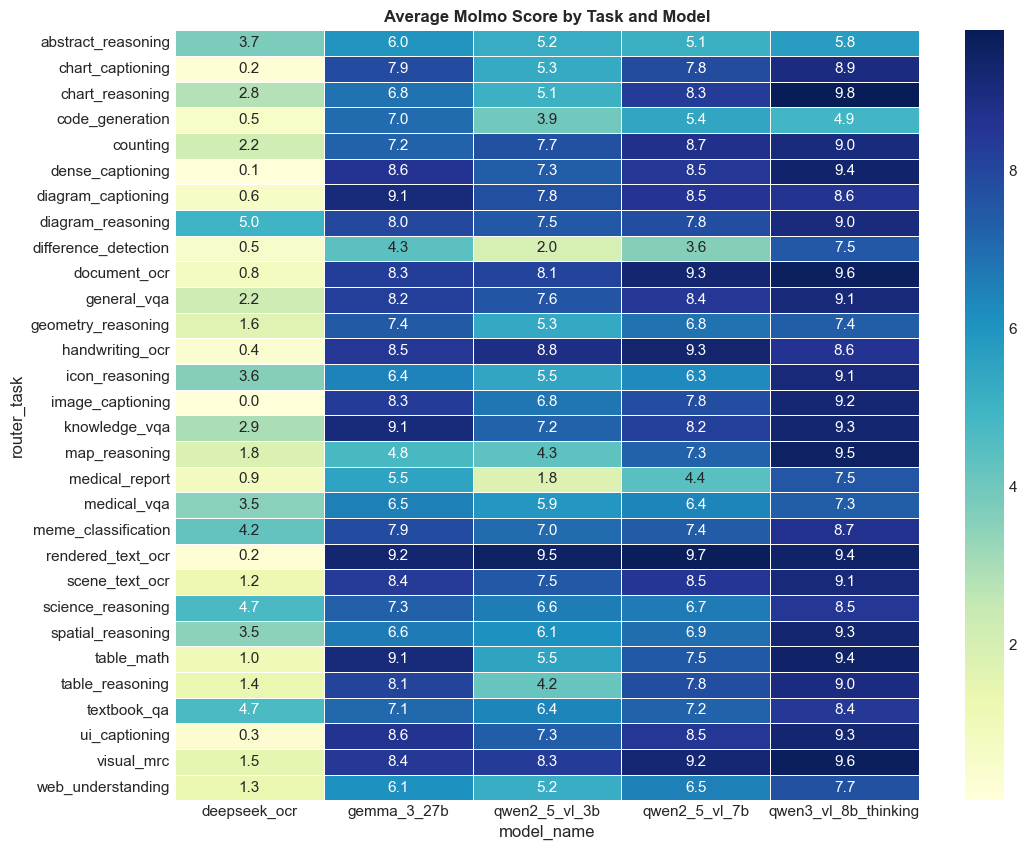

In [38]:
if 'judge_molmo_score' in df.columns and 'router_task' in df.columns:
    task_perf = df.pivot_table(index='router_task', columns='model_name', values='judge_molmo_score', aggfunc='mean')
    
    plt.figure(figsize=(12, 10))
    sns.heatmap(task_perf, annot=True, cmap="YlGnBu", fmt=".1f", linewidths=.5)
    plt.title("Average Molmo Score by Task and Model", fontweight='bold')
    plt.show()

## 8. Summary & Recommendations 

Based on the analysis above:
- **Best Overall Model**: Look at the highest average Molmo Score and Rank #1 %.
- **Agreement**: Check correlation heatmap. If Glider and Molmo interact well, we can trust automated metrics.
- **Calibration**: If the curve is strictly increasing, confidence is a useful routing signal.
- **Hardest Tasks**: Identified by the lowest row averages in the final heatmap.